In [1]:
!pip install clustering-benchmarks -q

In [2]:
import clustbench
data_url = "https://github.com/gagolews/clustering-data-v1/raw/v1.1.0"

In [3]:
battery_datasets_dict = {
                         'fcps': ['atom', 'chainlink', 'engytime', 'hepta', 'lsun', 'target', 'tetra', 'twodiamonds', 'wingnut'],
                         'g2mg': ['g2mg_4_10', 'g2mg_4_20', 'g2mg_4_30', 'g2mg_4_40', 'g2mg_4_50', 'g2mg_4_60', 'g2mg_4_70', 'g2mg_4_80', 'g2mg_4_90', 'g2mg_8_10', 'g2mg_8_20', 'g2mg_8_30', 'g2mg_8_40', 'g2mg_8_50', 'g2mg_8_60', 'g2mg_8_70', 'g2mg_8_80', 'g2mg_8_90', 'g2mg_16_10', 'g2mg_16_20', 'g2mg_16_30', 'g2mg_16_40', 'g2mg_16_50', 'g2mg_16_60', 'g2mg_16_70', 'g2mg_16_80', 'g2mg_16_90', 'g2mg_32_10', 'g2mg_32_20', 'g2mg_32_30', 'g2mg_32_40', 'g2mg_32_50', 'g2mg_32_60', 'g2mg_32_70', 'g2mg_32_80', 'g2mg_32_90', 'g2mg_64_10', 'g2mg_64_20', 'g2mg_64_30', 'g2mg_64_40', 'g2mg_64_50', 'g2mg_64_60', 'g2mg_64_70', 'g2mg_64_80', 'g2mg_64_90', 'g2mg_128_10', 'g2mg_128_20', 'g2mg_128_30', 'g2mg_128_40', 'g2mg_128_50', 'g2mg_128_60', 'g2mg_128_70', 'g2mg_128_80', 'g2mg_128_90'],
                         'h2mg': ['h2mg_4_10', 'h2mg_4_20', 'h2mg_4_30', 'h2mg_4_40', 'h2mg_4_50', 'h2mg_4_60', 'h2mg_4_70', 'h2mg_4_80', 'h2mg_4_90', 'h2mg_8_10', 'h2mg_8_20', 'h2mg_8_30', 'h2mg_8_40', 'h2mg_8_50', 'h2mg_8_60', 'h2mg_8_70', 'h2mg_8_80', 'h2mg_8_90', 'h2mg_16_10', 'h2mg_16_20', 'h2mg_16_30', 'h2mg_16_40', 'h2mg_16_50', 'h2mg_16_60', 'h2mg_16_70', 'h2mg_16_80', 'h2mg_16_90', 'h2mg_32_10', 'h2mg_32_20', 'h2mg_32_30', 'h2mg_32_40', 'h2mg_32_50', 'h2mg_32_60', 'h2mg_32_70', 'h2mg_32_80', 'h2mg_32_90', 'h2mg_64_10', 'h2mg_64_20', 'h2mg_64_30', 'h2mg_64_40', 'h2mg_64_50', 'h2mg_64_60', 'h2mg_64_70', 'h2mg_64_80', 'h2mg_64_90', 'h2mg_128_10', 'h2mg_128_20', 'h2mg_128_30', 'h2mg_128_40', 'h2mg_128_50', 'h2mg_128_60', 'h2mg_128_70', 'h2mg_128_80', 'h2mg_128_90'],
                         }

## Create autoencoder using pytorch

In [4]:
import torch
import torch.nn as nn
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

def autoencoder_feat_eng(X, n_embeddings=8):

  X = StandardScaler().fit_transform(X)
  X = torch.tensor(X, dtype=torch.float)

  # --- Autoencoder definition ---
  class Autoencoder(nn.Module):
      def __init__(self, input_dim, latent_dim=n_embeddings):
          super().__init__()
          self.encoder = nn.Sequential(
              nn.Linear(input_dim, 64),
              nn.ReLU(),
              nn.Linear(64, latent_dim)
          )
          self.decoder = nn.Sequential(
              nn.Linear(latent_dim, 64),
              nn.ReLU(),
              nn.Linear(64, input_dim)
          )

      def forward(self, x):
          z = self.encoder(x)
          x_hat = self.decoder(z)
          return x_hat, z

  # --- Train AE ---
  input_dim = X.shape[1] # Dynamically set input_dim
  model = Autoencoder(input_dim)
  optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
  criterion = nn.MSELoss()

  for epoch in range(100):
      x_hat, z = model(X)
      loss = criterion(x_hat, X)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

  # --- Cluster latent space ---
  with torch.no_grad():
      latent = model.encoder(X).numpy()

  return latent

## Function get_scores

Get the NCA score of a specific dataset using genie mst algorithm

In [5]:
import sklearn.cluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def get_scores(battery, dataset, apply_scale=False):
  b = clustbench.load_dataset(battery, dataset, url=data_url)

  X_transformed = b.data
  if apply_scale:
    # Scale the data
    scaler = StandardScaler()
    X_transformed = scaler.fit_transform(X_transformed)

  m = sklearn.cluster.AgglomerativeClustering(n_clusters=b.n_clusters[0])
  results = clustbench.fit_predict_many(m, X_transformed, b.n_clusters[0])
  scores = clustbench.get_score(b.labels[0], results)

  return scores

## Function get_scores_with_autoencoder

Get the NCA score of a specific dataset applying the autoencoder transformation to the data and then using genie mst algorithm

In [6]:
import sklearn.cluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def get_scores_with_autoencoder(battery, dataset, apply_scale=False, n_embeddings=2):
  b = clustbench.load_dataset(battery, dataset, url=data_url)

  X_transformed = autoencoder_feat_eng(b.data, n_embeddings=n_embeddings)

  if apply_scale:
    # Scale the data
    scaler = StandardScaler()
    X_transformed = scaler.fit_transform(X_transformed)

  m = sklearn.cluster.AgglomerativeClustering(n_clusters=b.n_clusters[0])
  results = clustbench.fit_predict_many(m, X_transformed, b.n_clusters[0])
  scores = clustbench.get_score(b.labels[0], results)

  return scores

## Execute get_scores on all datasets as baseline

In [7]:
import tqdm
import pandas as pd
columns = ['Battery', 'Dataset', 'Genie NCA Score']
df = pd.DataFrame(columns=columns)
scores_lists = {}
for col in columns:
  scores_lists[col] = []

for battery in tqdm.tqdm(battery_datasets_dict.keys(), desc="Processing Datasets"):
  for dataset in battery_datasets_dict[battery]:
    scores_lists['Battery'].append(battery)
    scores_lists['Dataset'].append(dataset)
    scores_lists['Genie NCA Score'].append(get_scores(battery, dataset))

df_baseline = pd.DataFrame.from_dict(scores_lists)

Processing Datasets: 100%|██████████| 3/3 [00:46<00:00, 15.43s/it]


In [8]:
df_baseline.style.apply(lambda row:['']*len(row), axis=1)

,Battery,Dataset,Genie NCA Score
0,fcps,atom,0.315000
1,fcps,chainlink,0.530000
2,fcps,engytime,0.864140
3,fcps,hepta,1.000000
4,fcps,lsun,0.637500
5,fcps,target,0.482094
6,fcps,tetra,0.983333
7,fcps,twodiamonds,1.000000
8,fcps,wingnut,0.775591
9,g2mg,g2mg_4_10,1.000000


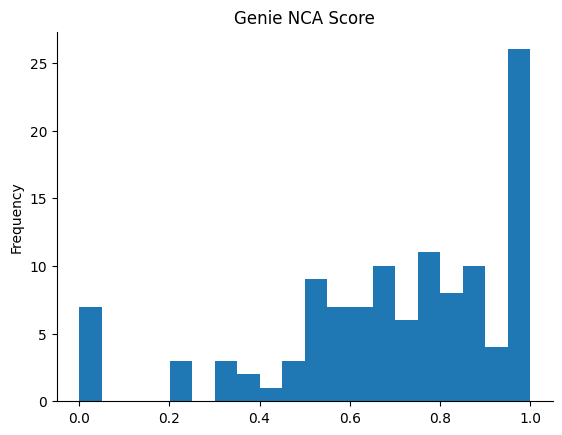

In [9]:
from matplotlib import pyplot as plt
df_baseline['Genie NCA Score'].plot(kind='hist', bins=20, title='Genie NCA Score')
plt.gca().spines[['top', 'right',]].set_visible(False)

## Execute get_scores_with_autoencoder on all datasets trying different numbers of embeddings (last hidden layer of the neural network)



In [10]:
n_embeddings_list = [2,4,8,16,32,64]

scores_lists = {}
for n_embs in tqdm.tqdm(n_embeddings_list, desc="Processing Datasets"):
  for battery in battery_datasets_dict.keys():
    for dataset in battery_datasets_dict[battery]:
      column_name = 'Genie+Autoencoder '+ str(n_embs) +' NCA Score'
      if column_name not in scores_lists:
        scores_lists[column_name] = []
      scores_lists[column_name].append(get_scores_with_autoencoder(battery, dataset, n_embeddings=n_embs))

df_ssnn = pd.DataFrame.from_dict(scores_lists)

Processing Datasets: 100%|██████████| 6/6 [09:25<00:00, 94.26s/it] 


In [11]:
df = pd.concat([df_baseline, df_ssnn], axis=1)

# Final Results

In [12]:
df['Genie+Autoencoder 2 NCA Score (Difference)'] = df['Genie+Autoencoder 2 NCA Score'] - df['Genie NCA Score']
df['Genie+Autoencoder 4 NCA Score (Difference)'] = df['Genie+Autoencoder 4 NCA Score'] - df['Genie NCA Score']
df['Genie+Autoencoder 8 NCA Score (Difference)'] = df['Genie+Autoencoder 8 NCA Score'] - df['Genie NCA Score']
df['Genie+Autoencoder 16 NCA Score (Difference)'] = df['Genie+Autoencoder 16 NCA Score'] - df['Genie NCA Score']
df['Genie+Autoencoder 32 NCA Score (Difference)'] = df['Genie+Autoencoder 32 NCA Score'] - df['Genie NCA Score']
df['Genie+Autoencoder 64 NCA Score (Difference)'] = df['Genie+Autoencoder 64 NCA Score'] - df['Genie NCA Score']

def highlight_scores(row):
    color = 'yellow'
    if row['Genie NCA Score'] < 0.8 and \
     (row['Genie+Autoencoder 2 NCA Score'] > 0.9 or
      row['Genie+Autoencoder 4 NCA Score'] > 0.9 or
      row['Genie+Autoencoder 8 NCA Score'] > 0.9 or
      row['Genie+Autoencoder 16 NCA Score'] > 0.9 or
      row['Genie+Autoencoder 32 NCA Score'] > 0.9 or
      row['Genie+Autoencoder 64 NCA Score'] > 0.9):
        return [f'background-color: {color}'] * len(row)
    return [''] * len(row)

df[df['Genie NCA Score']<0.8].style.apply(highlight_scores, axis=1)

,Battery,Dataset,Genie NCA Score,Genie+Autoencoder 2 NCA Score,Genie+Autoencoder 4 NCA Score,Genie+Autoencoder 8 NCA Score,Genie+Autoencoder 16 NCA Score,Genie+Autoencoder 32 NCA Score,Genie+Autoencoder 64 NCA Score,Genie+Autoencoder 2 NCA Score (Difference),Genie+Autoencoder 4 NCA Score (Difference),Genie+Autoencoder 8 NCA Score (Difference),Genie+Autoencoder 16 NCA Score (Difference),Genie+Autoencoder 32 NCA Score (Difference),Genie+Autoencoder 64 NCA Score (Difference)
0,fcps,atom,0.315000,0.305000,0.342500,0.530000,0.580000,0.390000,0.360000,-0.010000,0.027500,0.215000,0.265000,0.075000,0.045000
1,fcps,chainlink,0.530000,0.142000,0.066000,0.036000,0.282000,0.362000,0.386000,-0.388000,-0.464000,-0.494000,-0.248000,-0.168000,-0.144000
4,fcps,lsun,0.637500,0.822500,0.645000,0.615000,0.805000,0.672500,0.670000,0.185000,0.007500,-0.022500,0.167500,0.035000,0.032500
5,fcps,target,0.482094,0.515152,0.451791,0.305785,0.308540,0.308540,0.438017,0.033058,-0.030303,-0.176309,-0.173554,-0.173554,-0.044077
8,fcps,wingnut,0.775591,1.000000,1.000000,1.000000,1.000000,1.000000,0.663386,0.224409,0.224409,0.224409,0.224409,0.224409,-0.112205
14,g2mg,g2mg_4_60,0.773452,0.736359,0.807294,0.719601,0.653814,0.796413,0.525063,-0.037093,0.033842,-0.053851,-0.119638,0.022961,-0.248389
15,g2mg,g2mg_4_70,0.707755,0.781978,0.629559,0.697723,0.778984,0.549801,0.266577,0.074223,-0.078197,-0.010032,0.071229,-0.157954,-0.441178
16,g2mg,g2mg_4_80,0.646191,0.594684,0.768205,0.394359,0.501810,0.546990,0.640170,-0.051507,0.122014,-0.251832,-0.144381,-0.099201,-0.006021
17,g2mg,g2mg_4_90,0.636224,0.522158,0.746018,0.198720,0.554467,0.574334,0.649867,-0.114066,0.109794,-0.437504,-0.081757,-0.061890,0.013644
22,g2mg,g2mg_8_50,0.755628,0.882348,0.585178,0.823981,0.773896,0.732211,0.805350,0.126720,-0.170450,0.068353,0.018269,-0.023417,0.049723


In [13]:
print(len(df),len(df[df['Genie NCA Score']<0.8]))

117 69
